In [1]:
import pandas as pd
import numpy as np
import os
import random
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import shap
from scripts.preprocessing import load_data, test_stationarity, create_lagged_features
from scripts.econometrics_models import ols_regression, arima_model, sarimax_model, test_autocorrelation, test_heteroskedasticity, grid_search_sarimax
from scripts.ml_models import prepare_ml_data, train_xgb_model, tune_xgb_model, scale_data
from scripts.evaluation import calculate_metrics
from scripts.visualization import plot_predictions, plot_feature_importance, plot_shap_summary, plot_multiple_preds

import warnings
warnings.filterwarnings('ignore')

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

c:\Users\lapto\Magisterka_Pawel\master_degree\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_data('data/dane_2010plus.xlsx')
df.describe()

,stopa_bezrobocia,Produkt krajowy brutto [GUS],płaca_minimalna [brutto],inflacja [%],przyrost naturalny,Przeciętne_msc_wynag_brutto_sektor_przedsię [zł],Oferty pracy - stan na koniec miesiąca
count,180.000000,1.800000e+02,180.000000,180.000000,180.000000,180.000000,180.000000
mean,8.626667,5.542330e+05,2243.933333,3.591667,-4499.444444,4997.643333,68422.222222
std,3.224810,1.733330e+05,826.486064,4.344751,7961.081993,1428.804569,23489.770876
min,4.900000,3.300532e+05,1317.000000,-1.600000,-39200.000000,3231.130000,22000.000000
25%,5.675000,4.156350e+05,1600.000000,1.075000,-8600.000000,3854.397500,48325.000000
50%,7.050000,5.044142e+05,2000.000000,2.550000,-2650.000000,4511.680000,65250.000000
75%,11.900000,6.509255e+05,2800.000000,4.300000,725.000000,5803.245000,85425.000000
max,14.400000,1.013360e+06,4300.000000,18.400000,7900.000000,8821.250000,120300.000000


In [3]:
stationarity_result = test_stationarity(df['stopa_bezrobocia'])
print("Wynik testu stacjonarności:")
stationarity_result

Wynik testu stacjonarności:


{'ADF Statistic': np.float64(-1.4234145794904554),
 'p-value': np.float64(0.571000834025678),
 'Critical Values': {'1%': np.float64(-3.470616369591229),
  '5%': np.float64(-2.8792214018977655),
  '10%': np.float64(-2.57619681359045)},
 'Stationary': np.False_}

In [4]:
df['stopa_bezrobocia_diff'] = df['stopa_bezrobocia'].diff()

stationarity_result = test_stationarity(df['stopa_bezrobocia_diff'].dropna())
print("Wynik testu stacjonarności (dla przyrostu):")
stationarity_result

Wynik testu stacjonarności (dla przyrostu):


{'ADF Statistic': np.float64(-2.219845299103094),
 'p-value': np.float64(0.19912175853140157),
 'Critical Values': {'1%': np.float64(-3.470616369591229),
  '5%': np.float64(-2.8792214018977655),
  '10%': np.float64(-2.57619681359045)},
 'Stationary': np.False_}

In [5]:
df['stopa_bezrobocia_diff2'] = df['stopa_bezrobocia_diff'].diff()

stationarity_result = test_stationarity(df['stopa_bezrobocia_diff2'].dropna())
print("ADF dla 2. różnicowania:")
stationarity_result

ADF dla 2. różnicowania:


{'ADF Statistic': np.float64(-4.9160835077721154),
 'p-value': np.float64(3.244569918518262e-05),
 'Critical Values': {'1%': np.float64(-3.470616369591229),
  '5%': np.float64(-2.8792214018977655),
  '10%': np.float64(-2.57619681359045)},
 'Stationary': np.True_}

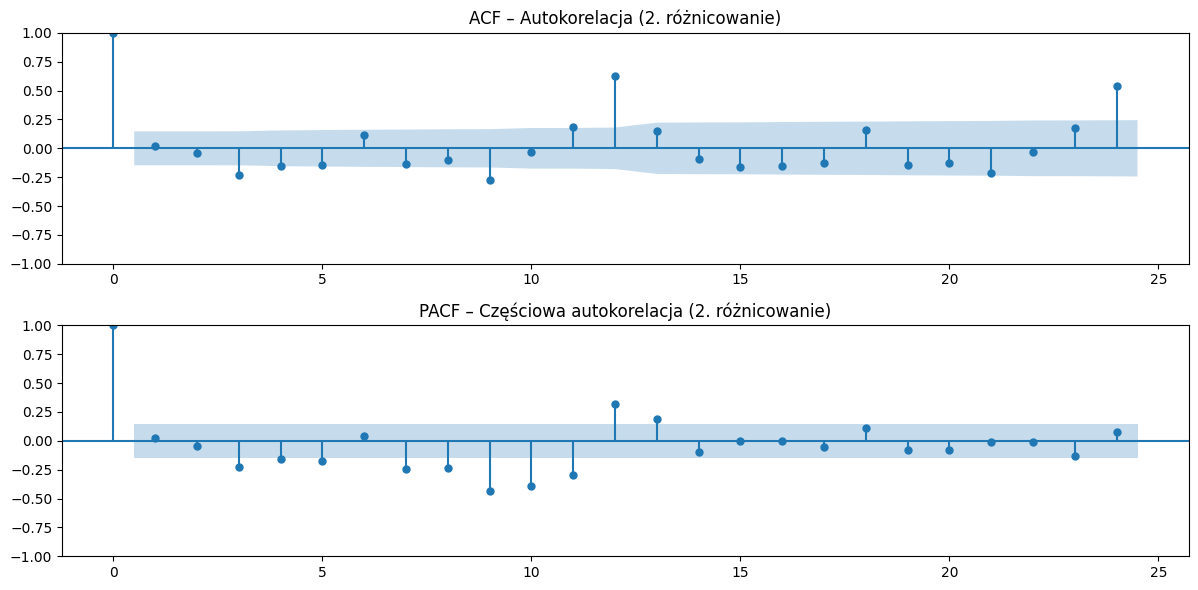

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(df['stopa_bezrobocia_diff2'].dropna(), lags=24, ax=ax[0])
ax[0].set_title('ACF – Autokorelacja (2. różnicowanie)')

plot_pacf(df['stopa_bezrobocia_diff2'].dropna(), lags=24, ax=ax[1])
ax[1].set_title('PACF – Częściowa autokorelacja (2. różnicowanie)')

plt.tight_layout()
plt.show()

SARIMAX (diff 2)

In [33]:
df['stopa_bezrobocia_diff']  = df['stopa_bezrobocia'].diff()
df['stopa_bezrobocia_diff2'] = df['stopa_bezrobocia_diff'].diff()
df2   = df.dropna(subset=['stopa_bezrobocia_diff2'])
train_end     = -24
series_train  = df2['stopa_bezrobocia_diff2'].iloc[:train_end]
series_test   = df2['stopa_bezrobocia_diff2'].iloc[ train_end:]

In [34]:
result = grid_search_sarimax(
    series=series_train,
    p_range=range(0, 3),
    d_range=[0],
    q_range=range(0, 3),
    P_range=range(0, 2),
    D_range=[0],
    Q_range=range(0, 2),
    seasonal_period=12,
    verbose=False
)

In [35]:
best_sarimax_diff2 = result['best_model']
print("Najlepsze parametry:", result['order'], result['seasonal_order'])

Najlepsze parametry: (0, 0, 1) (1, 0, 1, 12)


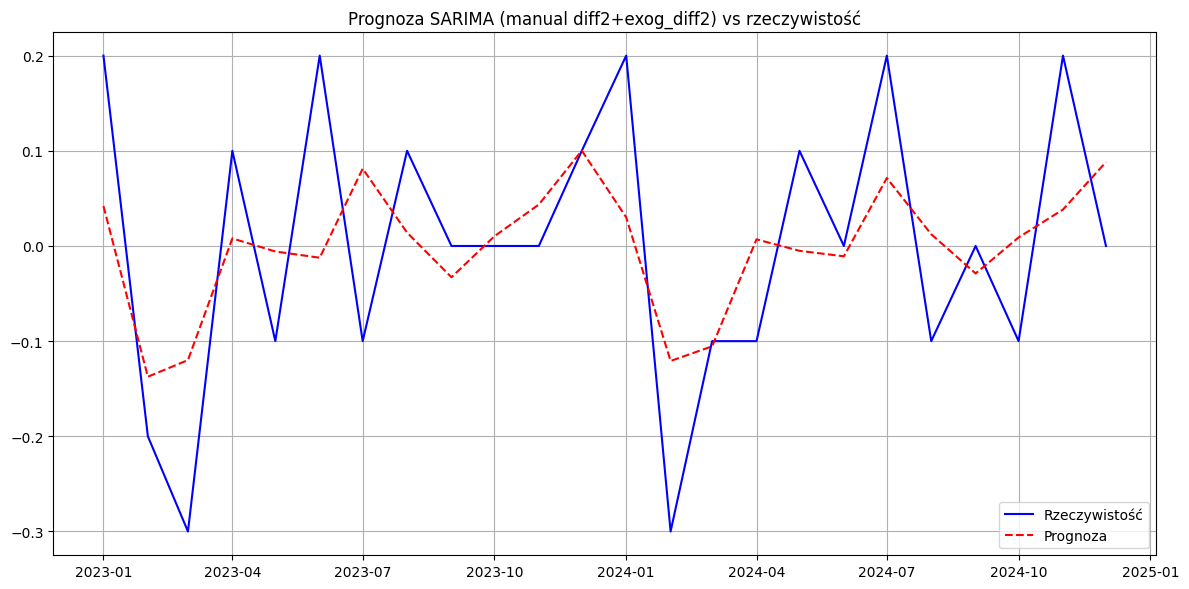

In [36]:
forecast_diff2 = best_sarimax_diff2.get_forecast(
    steps=len(series_test)
).predicted_mean
forecast_diff2.index = series_test.index
y_test = series_test

plot_predictions(y_test, forecast_diff2, title="Prognoza SARIMA (manual diff2+exog_diff2) vs rzeczywistość")

Poprawiona rekonstrukcja SARIMA na diff2 + exog_diff2 → y:
 {'MSE': 0.18693115469082444, 'RMSE': np.float64(0.4323553569586301), 'MAE': 0.3868749494851483}


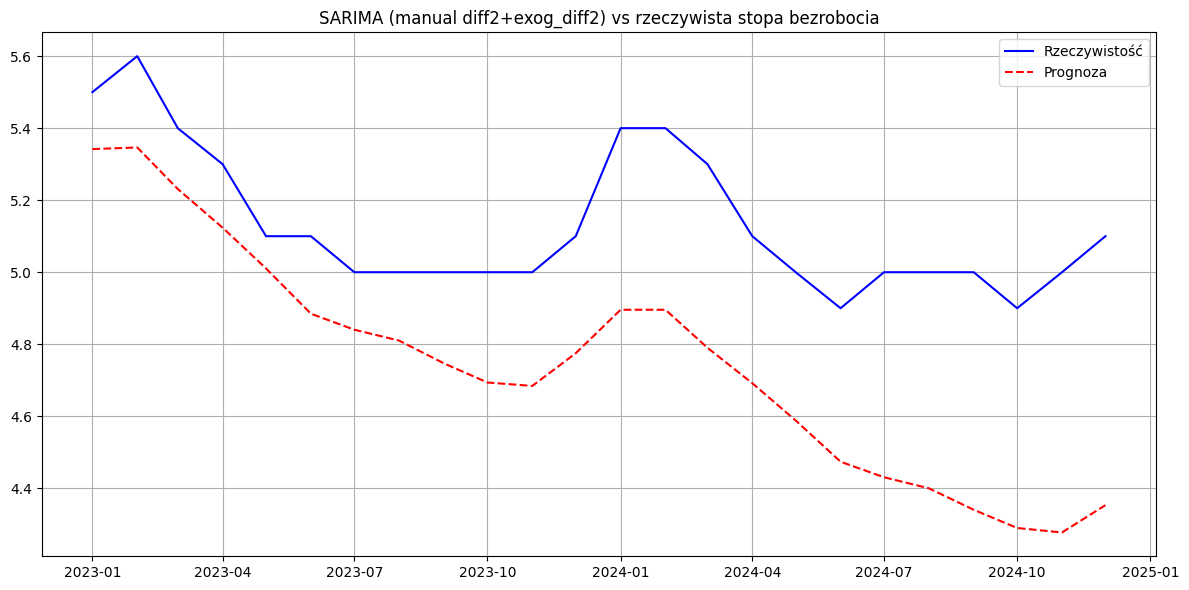

In [37]:
# 1) Indeks pierwszego kroku testowego w df2
first_test_idx = series_test.index[0]  # np. '2023-01-01'
loc = df2.index.get_loc(first_test_idx)

# 2) Indeks ostatniego punktu train w df2
last_train_loc = loc - 1
last_train_idx = df2.index[last_train_loc]

# 3) Ostatni yₜ₋₁ i Δyₜ₋₁ z df2
y_t1       = df.loc[last_train_idx, 'stopa_bezrobocia']
delta_prev = df2.loc[last_train_idx, 'stopa_bezrobocia_diff']

# 4) Rekonstrukcja
delta_forecast = delta_prev + np.cumsum(forecast_diff2.values)
level_forecast = y_t1    + np.cumsum(delta_forecast)

sarima_diff2_forecast = pd.Series(level_forecast, index=series_test.index)

# 5) Metryki i wykres
y_true = df['stopa_bezrobocia'].iloc[-24:]

metrics_sarima_diff2 = calculate_metrics(y_true, sarima_diff2_forecast)
print("Poprawiona rekonstrukcja SARIMA na diff2 + exog_diff2 → y:\n", metrics_sarima_diff2)

plot_predictions(
    y_true,
    sarima_diff2_forecast,
    title="SARIMA (manual diff2+exog_diff2) vs rzeczywista stopa bezrobocia"
)

SARIMAX (diff 2) z dodatkowymi zmiennymi

In [12]:
train = df.iloc[:-24]
test  = df.iloc[-24:]

series_train = train['stopa_bezrobocia']
series_test  = test ['stopa_bezrobocia']

exog_vars = [
    'Produkt krajowy brutto [GUS]',
    'płaca_minimalna [brutto]',
    'inflacja [%]',
    'przyrost naturalny',
    'Przeciętne_msc_wynag_brutto_sektor_przedsię [zł]',
    'Oferty pracy - stan na koniec miesiąca'
]
exog_train = train[exog_vars]
exog_test  = test [exog_vars]

In [13]:
result = grid_search_sarimax(
    series         = series_train,
    exog           = exog_train,
    p_range        = range(0, 3),
    d_range        = [2],       # automatyczne różnicowanie
    q_range        = range(0, 3),
    P_range        = range(0, 2),
    D_range        = [1],          # sezonowe różnicowanie
    Q_range        = range(0, 2),
    seasonal_period=12,
    verbose        = True
)

best_sarimax = result['best_model']
print("Najlepsze parametry:", result['order'], result['seasonal_order'])

Tested SARIMAX(0, 2, 0)x(0, 1, 0, 12) - AIC: 444.76, BIC: 465.40 (1/36)
Tested SARIMAX(0, 2, 0)x(0, 1, 1, 12) - AIC: -127.12, BIC: -104.24 (2/36)
Tested SARIMAX(0, 2, 0)x(1, 1, 0, 12) - AIC: -131.15, BIC: -108.21 (3/36)
Tested SARIMAX(0, 2, 0)x(1, 1, 1, 12) - AIC: -127.22, BIC: -101.48 (4/36)
Tested SARIMAX(0, 2, 1)x(0, 1, 0, 12) - AIC: -138.97, BIC: -115.43 (5/36)
Tested SARIMAX(0, 2, 1)x(0, 1, 1, 12) - AIC: -147.03, BIC: -121.36 (6/36)
Tested SARIMAX(0, 2, 1)x(1, 1, 0, 12) - AIC: -149.64, BIC: -123.83 (7/36)
Tested SARIMAX(0, 2, 1)x(1, 1, 1, 12) - AIC: -146.45, BIC: -117.93 (8/36)
Tested SARIMAX(0, 2, 2)x(0, 1, 0, 12) - AIC: -139.30, BIC: -112.89 (9/36)
Tested SARIMAX(0, 2, 2)x(0, 1, 1, 12) - AIC: -145.70, BIC: -117.26 (10/36)
Tested SARIMAX(0, 2, 2)x(1, 1, 0, 12) - AIC: -150.54, BIC: -121.86 (11/36)
Tested SARIMAX(0, 2, 2)x(1, 1, 1, 12) - AIC: -145.52, BIC: -114.24 (12/36)
Tested SARIMAX(1, 2, 0)x(0, 1, 0, 12) - AIC: -132.26, BIC: -108.67 (13/36)
Tested SARIMAX(1, 2, 0)x(0, 1, 1, 12

SARIMAX (oryginał) na zbiorze testowym:
{'MSE': 0.7021651395494786, 'RMSE': np.float64(0.837952945904171), 'MAE': 0.6709877633093271}


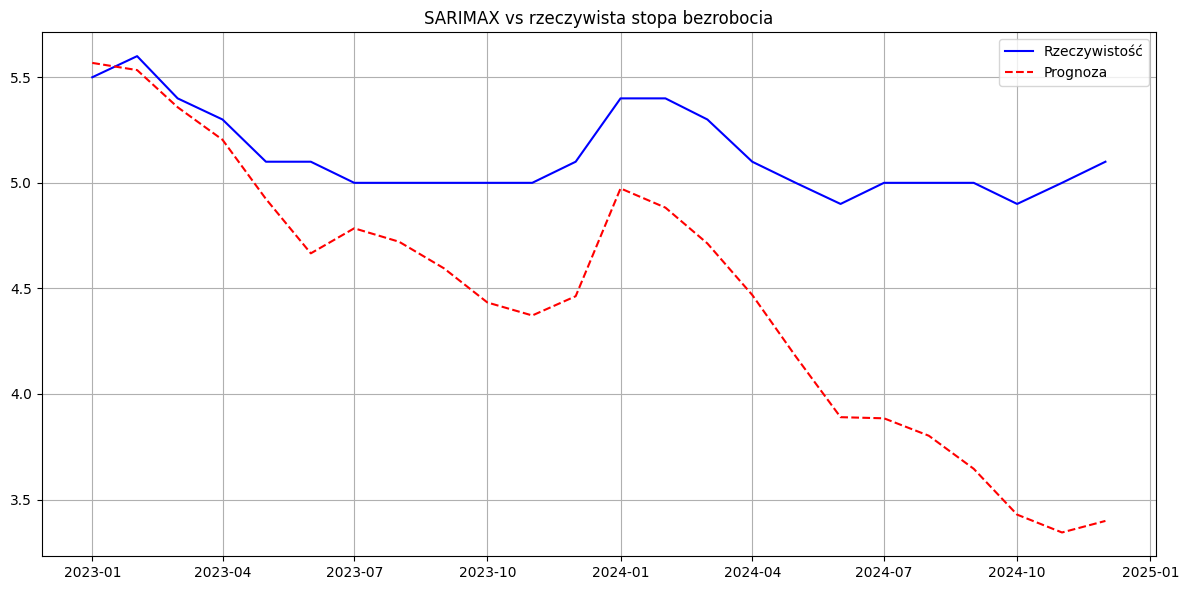

In [14]:
sarima_diff2_exog_forecast = best_sarimax.get_forecast(
    steps=len(series_test),
    exog=exog_test
).predicted_mean
sarima_diff2_exog_forecast.index = series_test.index

metrics_sarima_diff2_exog = calculate_metrics(series_test, sarima_diff2_exog_forecast)
print("SARIMAX (oryginał) na zbiorze testowym:")
print(metrics_sarima_diff2_exog)

plot_predictions(
    series_test,
    sarima_diff2_exog_forecast,
    title="SARIMAX vs rzeczywista stopa bezrobocia"
)

In [15]:
# Wyciągnięcie współczynników i p-value
params_table = pd.DataFrame({
    'coef': best_sarimax.params,
    'pvalue': best_sarimax.pvalues
})
print("Tabela parametrów SARIMAX:")
display(params_table)

# Podział na AR/MA, Seasonal, Exogenous
ar_ma = params_table.loc[[c for c in params_table.index if c.startswith('ar.') or c.startswith('ma.')]]
seasonal = params_table.loc[[c for c in params_table.index if '.S.' in c]]
exog_coefs = params_table.loc[exog_vars]

Tabela parametrów SARIMAX:


,coef,pvalue
Produkt krajowy brutto [GUS],-2.996150e-06,7.264843e-03
płaca_minimalna [brutto],1.088096e-03,1.189320e-03
inflacja [%],-2.467422e-03,9.161936e-01
przyrost naturalny,6.502565e-06,1.352238e-05
Przeciętne_msc_wynag_brutto_sektor_przedsię [zł],-2.478182e-04,1.888443e-01
Oferty pracy - stan na koniec miesiąca,-9.347609e-07,5.572271e-01
ma.L1,-4.893741e-01,8.576077e-07
ma.L2,-4.622384e-02,7.004565e-01
ar.S.L12,-3.131874e-01,2.659636e-03
sigma2,1.866809e-02,3.990454e-11


In [16]:
# 1. Wyodrębnij istotne exog_vars
significant_exog = exog_coefs[exog_coefs['pvalue'] < 0.05].index.tolist()
print("Znaczące zmienne egzogeniczne (p<0.05):", significant_exog)

# 2. Przygotuj nowe exog dla train/test
exog_train_sig = exog_train[significant_exog]
exog_test_sig  = exog_test[significant_exog]

# 3. Grid search SARIMAX na oryginale z wybranymi exogenous
result_sig = grid_search_sarimax(
    series=series_train,
    exog=exog_train_sig,
    p_range=range(0, 3),
    d_range=[1, 2],
    q_range=range(0, 3),
    P_range=range(0, 2),
    D_range=[1],
    Q_range=range(0, 2),
    seasonal_period=12,
    verbose=False
)

best_sarimax_sig = result_sig['best_model']
print("Optymalne parametry (z istotnymi exog):", result_sig['order'], result_sig['seasonal_order'])

Znaczące zmienne egzogeniczne (p<0.05): ['Produkt krajowy brutto [GUS]', 'płaca_minimalna [brutto]', 'przyrost naturalny']
Optymalne parametry (z istotnymi exog): (2, 1, 0) (0, 1, 1, 12)


SARIMAX (tylko istotne exog) na testowym:
{'MSE': 0.18031441653783142, 'RMSE': np.float64(0.42463445048397974), 'MAE': 0.37041310817434087}


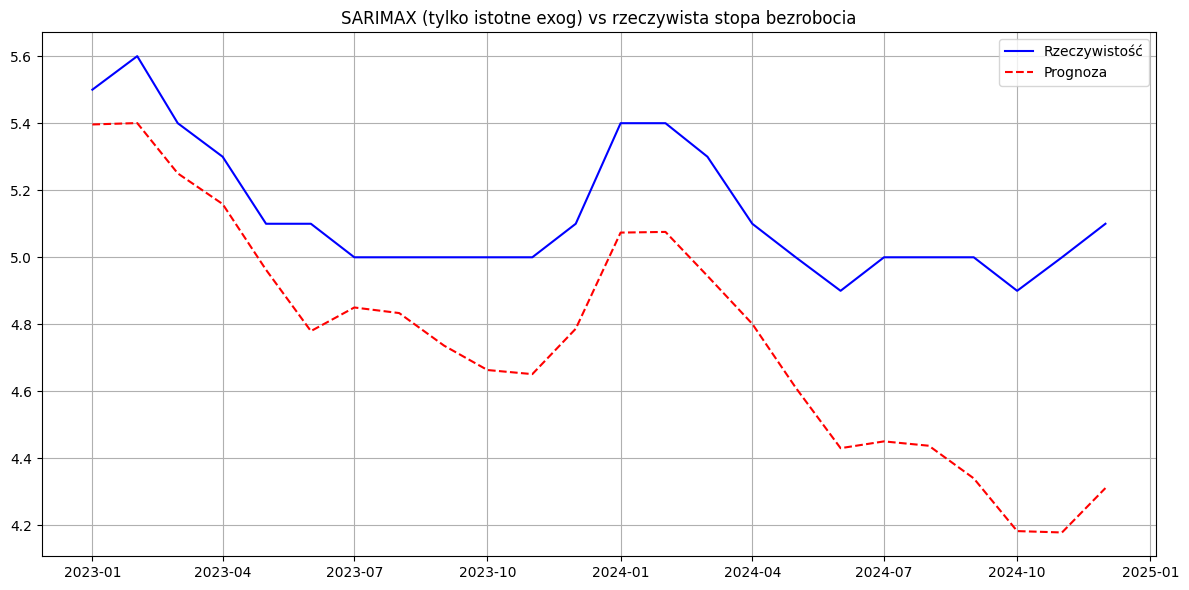

In [17]:
# 4. Prognoza i ewaluacja
sarima_diff2_exog_forecast = best_sarimax_sig.get_forecast(
    steps=len(series_test),
    exog=exog_test_sig
).predicted_mean
sarima_diff2_exog_forecast.index = series_test.index

metrics_sarima_diff2_exog = calculate_metrics(series_test, sarima_diff2_exog_forecast)
print("SARIMAX (tylko istotne exog) na testowym:")
print(metrics_sarima_diff2_exog)

plot_predictions(
    series_test,
    sarima_diff2_exog_forecast,
    title="SARIMAX (tylko istotne exog) vs rzeczywista stopa bezrobocia"
)

XGBoost

In [18]:
# Przygotowanie danych (target to diff2)
X_ml, y_ml = prepare_ml_data(df, target_col='stopa_bezrobocia_diff2', lag_range=12)

# Podział na zbiór treningowy i testowy
X_train, X_test = X_ml.iloc[:-24], X_ml.iloc[-24:]
y_train, y_test = y_ml.iloc[:-24], y_ml.iloc[-24:]

# Czyszczenie nazw kolumn z niedozwolonych znaków
X_train.columns = X_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<>]', '', regex=True)


In [19]:
X_train_scaled, X_test_scaled, scaler = scale_data(X_train, X_test)

xgb_model = train_xgb_model(X_train_scaled, y_train, use_optuna=True, n_trials=200)
xgb_predictions = xgb_model.predict(X_test_scaled)

[I 2025-07-19 16:57:47,897] A new study created in memory with name: no-name-655de0f8-a7b5-4e03-b801-fefadf01bf38
[I 2025-07-19 16:57:47,960] Trial 0 finished with value: 0.19046533818135403 and parameters: {'n_estimators': 139, 'learning_rate': 0.010650213261982951, 'max_depth': 3, 'subsample': 0.5975573631933124, 'colsample_bytree': 0.6636446639310781, 'gamma': 1.638076213543611, 'min_child_weight': 8, 'reg_alpha': 0.08851196762361735, 'reg_lambda': 0.18437100032713205}. Best is trial 0 with value: 0.19046533818135403.
[I 2025-07-19 16:57:48,003] Trial 1 finished with value: 0.19381155509014839 and parameters: {'n_estimators': 93, 'learning_rate': 0.04983856843306716, 'max_depth': 8, 'subsample': 0.702009032629015, 'colsample_bytree': 0.8166810712894077, 'gamma': 1.937319138427166, 'min_child_weight': 10, 'reg_alpha': 0.3951046382647958, 'reg_lambda': 0.930696271503013}. Best is trial 0 with value: 0.19046533818135403.
[I 2025-07-19 16:57:48,078] Trial 2 finished with value: 0.182450

{'MSE': 0.060144343890556146, 'RMSE': np.float64(0.24524343801732218), 'MAE': 0.20475665424019085}


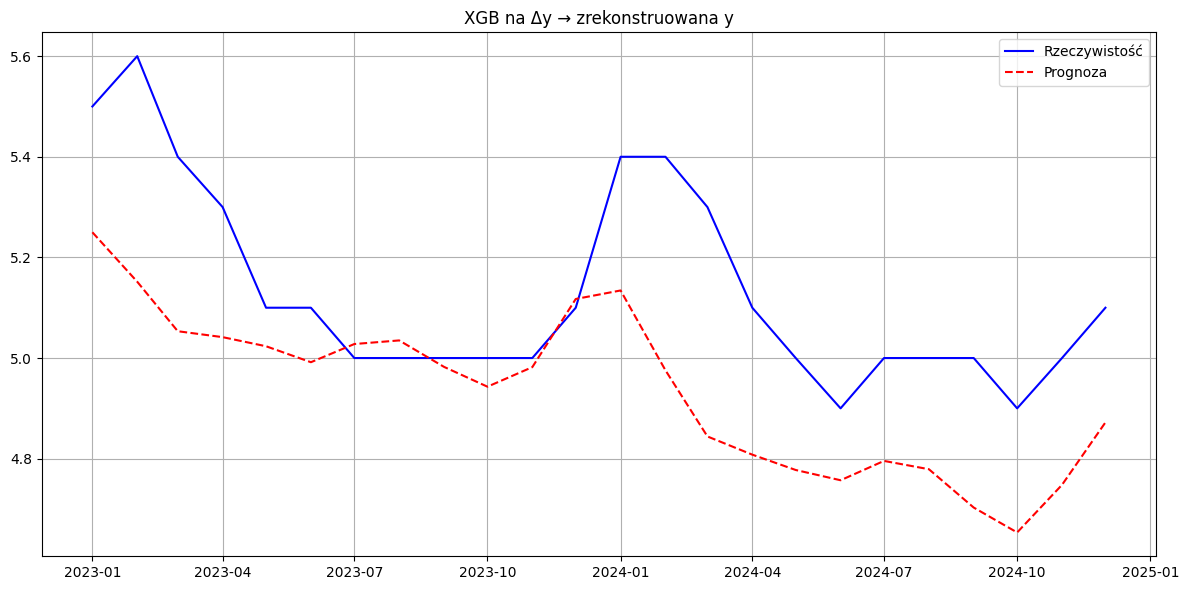

In [20]:
# predykcja Δ y
y_pred_diff = xgb_model.predict(X_test_scaled)

# rekonstrukcja:  yₜ = yₜ₋₁ + Δ yₜ
y_t0 = df['stopa_bezrobocia'].iloc[-25]  # ostatnia wartość przed testem
y_pred_level = y_t0 + np.cumsum(y_pred_diff)
xgb_level_forecast = pd.Series(y_pred_level, index=df.index[-24:])

# ewaluacja
metrics_xgb = calculate_metrics(df['stopa_bezrobocia'].iloc[-24:], xgb_level_forecast)
print(metrics_xgb)
plot_predictions(df['stopa_bezrobocia'].iloc[-24:], xgb_level_forecast,
                 title="XGB na Δy → zrekonstruowana y")

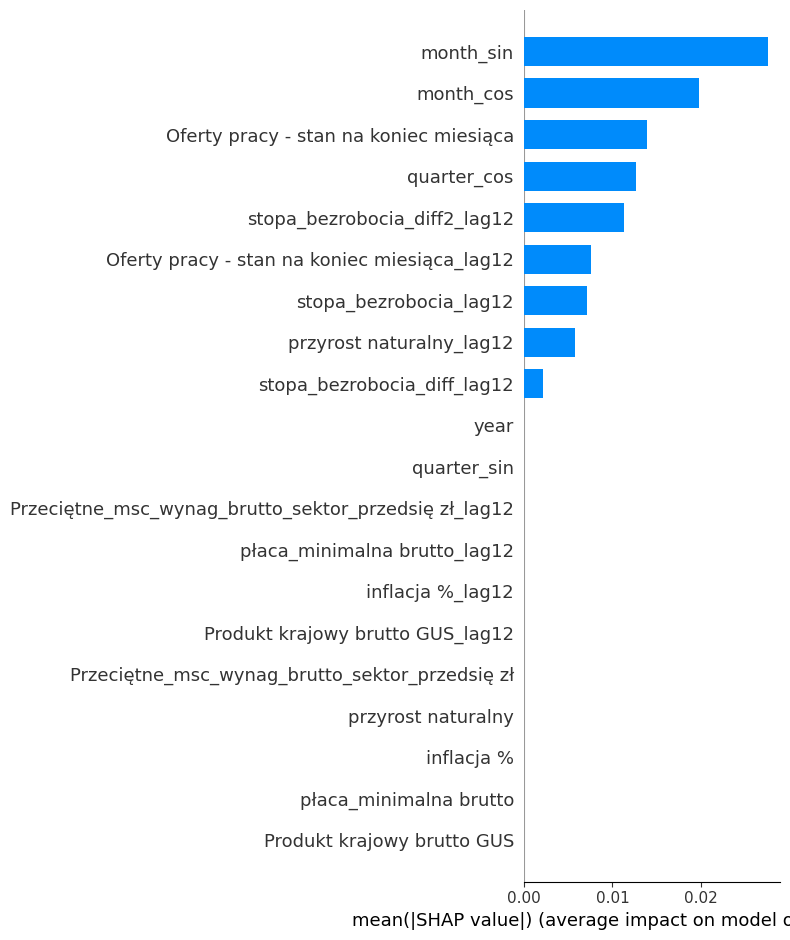

In [21]:
# 1. Stwórz Explainer i oblicz wartości SHAP
explainer = shap.Explainer(xgb_model, X_test_scaled, feature_names=X_test.columns)
shap_values = explainer(X_test_scaled)

# 2. Podsumowanie – wykres wartości średnich SHAP
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    feature_names=X_test.columns, 
    plot_type="bar"
)

[I 2025-07-19 16:58:18,040] A new study created in memory with name: no-name-aad6ad3b-d259-4ec9-9d23-2d9951434e8a


SHAP-selected features (8): ['Oferty pracy - stan na koniec miesiąca', 'stopa_bezrobocia_lag12', 'przyrost naturalny_lag12', 'Oferty pracy - stan na koniec miesiąca_lag12', 'stopa_bezrobocia_diff2_lag12', 'month_sin', 'month_cos', 'quarter_cos']


[I 2025-07-19 16:58:18,268] Trial 0 finished with value: 0.1876364235606078 and parameters: {'n_estimators': 300, 'learning_rate': 0.21125213862076495, 'max_depth': 3, 'subsample': 0.6118125115922397, 'colsample_bytree': 0.6934499751298437, 'gamma': 1.8530064298883415, 'min_child_weight': 10, 'reg_alpha': 0.00807748779341122, 'reg_lambda': 0.7708863538918644}. Best is trial 0 with value: 0.1876364235606078.
[I 2025-07-19 16:58:18,379] Trial 1 finished with value: 0.19746222474451783 and parameters: {'n_estimators': 219, 'learning_rate': 0.18048115370545062, 'max_depth': 7, 'subsample': 0.7888945986218621, 'colsample_bytree': 0.5921426709828912, 'gamma': 3.2612381179851657, 'min_child_weight': 1, 'reg_alpha': 0.20043533471021935, 'reg_lambda': 0.5331605923676483}. Best is trial 0 with value: 0.1876364235606078.
[I 2025-07-19 16:58:18,498] Trial 2 finished with value: 0.19819037154800356 and parameters: {'n_estimators': 280, 'learning_rate': 0.04748513500279951, 'max_depth': 7, 'subsampl

XGBoost (SHAP-selected) na testowym:
{'MSE': 0.028527963998799585, 'RMSE': np.float64(0.16890223207169167), 'MAE': 0.14029733394272625}


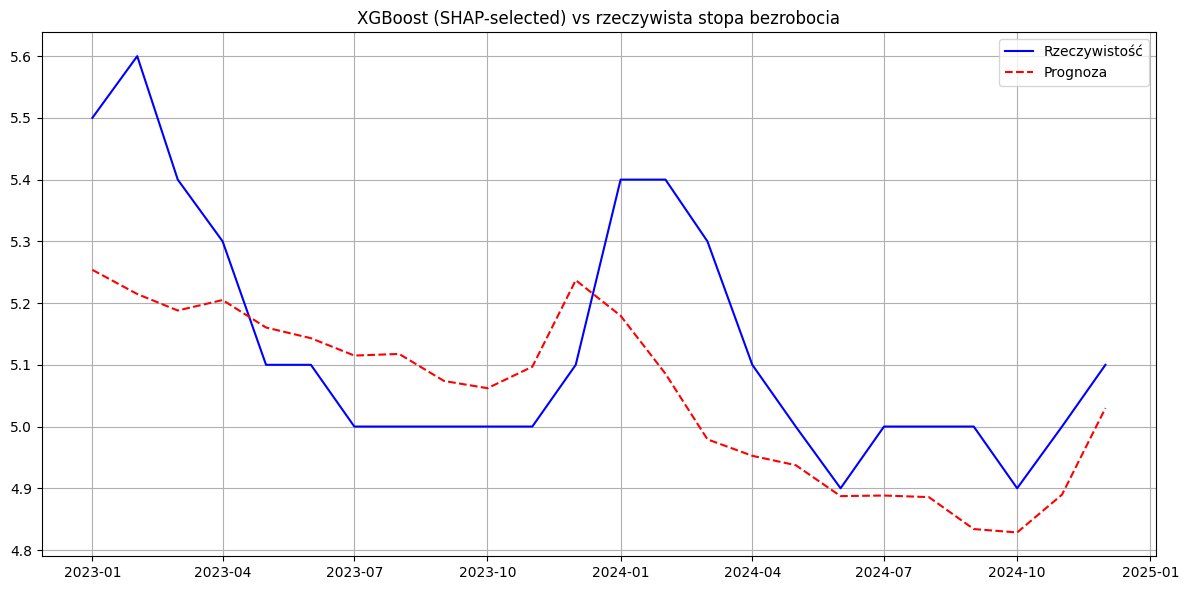

In [22]:
# 1. Oblicz średnie |SHAP| i wybierz cechy z wartością > 0
shap_abs = np.abs(shap_values.values)
shap_mean = pd.Series(shap_abs.mean(axis=0), index=X_test.columns)
selected_feats = shap_mean[shap_mean > 0.005].index.tolist()
print(f"SHAP-selected features ({len(selected_feats)}):", selected_feats)

# 2. Przygotuj X dla wybranych cech
X_train_sig = X_train[selected_feats]
X_test_sig  = X_test[selected_feats]

# 3. Skalowanie wybranych cech
X_train_sig_s, X_test_sig_s, _ = scale_data(X_train_sig, X_test_sig)

# 4. Trenowanie nowego modelu
model_xgb_sig = train_xgb_model(X_train_sig_s, y_train, use_optuna=True, n_trials=200)

# 5. Predykcja Δy i rekonstrukcja poziomu
y_pred_diff_sig = model_xgb_sig.predict(X_test_sig_s)
level_forecast_sig = y_t0 + np.cumsum(y_pred_diff_sig)
xgb_sig_forecast = pd.Series(level_forecast_sig, index=X_test_sig.index)

# 6. Ewaluacja metryk i wykres
metrics_xgb_sig = calculate_metrics(y_true, xgb_sig_forecast)
print("XGBoost (SHAP-selected) na testowym:")
print(metrics_xgb_sig)

plot_predictions(
    y_true,
    xgb_sig_forecast,
    title="XGBoost (SHAP-selected) vs rzeczywista stopa bezrobocia"
)

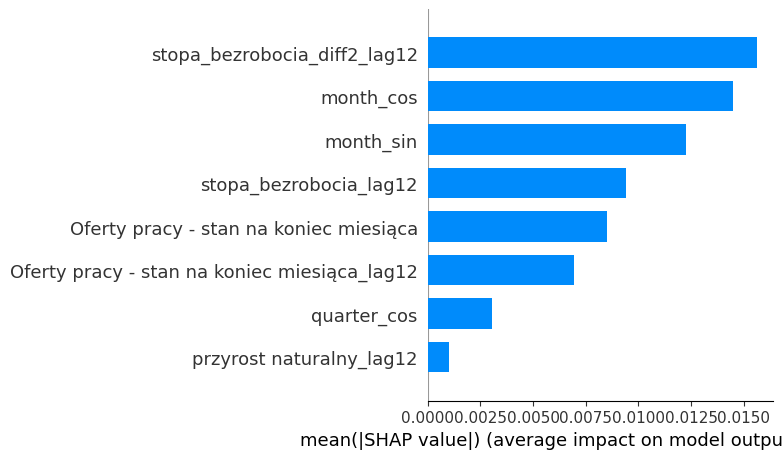

In [23]:
# 1. Stwórz Explainer i oblicz wartości SHAP
explainer = shap.Explainer(model_xgb_sig, X_test_sig_s, feature_names=X_test_sig.columns)
shap_values = explainer(X_test_sig_s)

# 2. Podsumowanie – wykres wartości średnich SHAP
shap.summary_plot(
    shap_values, 
    X_test_sig_s, 
    feature_names=X_test_sig.columns, 
    plot_type="bar"
)

Połączenie wielu modeli

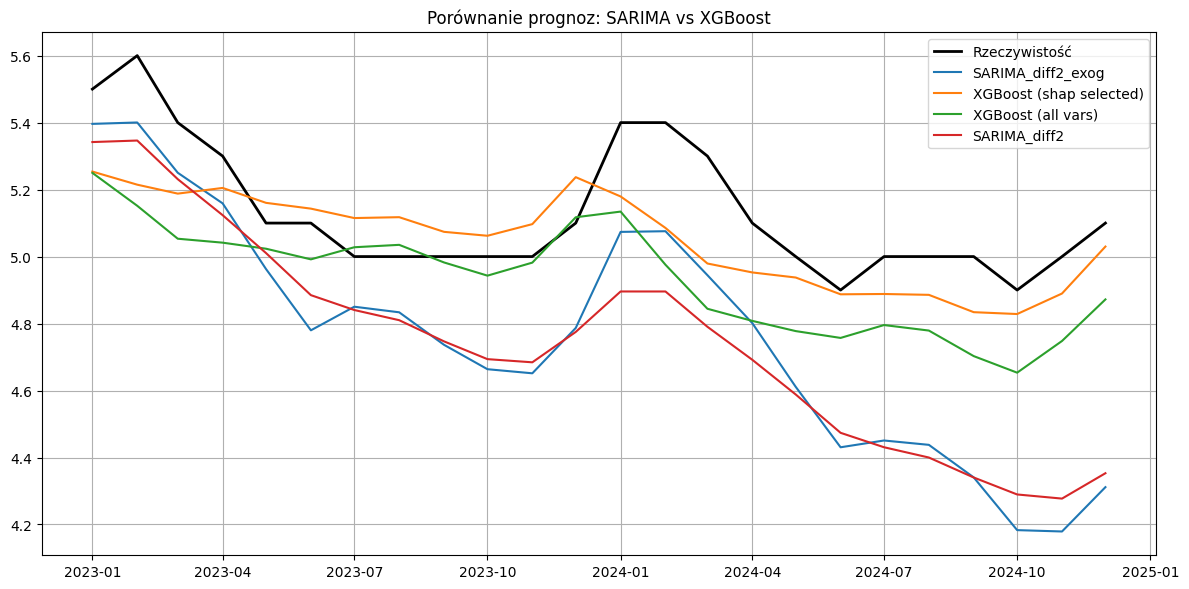

In [24]:
plot_multiple_preds(
    y_true=df['stopa_bezrobocia'].iloc[-24:],
    predictions={
        'SARIMA_diff2_exog': sarima_diff2_exog_forecast,
        'XGBoost (shap selected)': xgb_sig_forecast, 
        'XGBoost (all vars)': xgb_level_forecast, 
        'SARIMA_diff2': sarima_diff2_forecast
    },
    title='Porównanie prognoz: SARIMA vs XGBoost'
)

In [25]:
# Tworzymy ramkę z wynikami
results_summary = pd.DataFrame([
    {'Model': 'SARIMA_diff2', **metrics_sarima_diff2},
    {'Model': 'SARIMA_diff2_exog', **metrics_sarima_diff2_exog},
    {'Model': 'XGBoost (all vars)', **metrics_xgb},
    {'Model': 'XGBoost (shap selected)', **metrics_xgb_sig}  
])

# Zaokrąglenie do 4 miejsc
results_summary = results_summary.round(4)
results_summary.set_index('Model', inplace=True)

print(results_summary)

                            MSE    RMSE     MAE
Model                                          
SARIMA_diff2             0.1869  0.4324  0.3869
SARIMA_diff2_exog        0.1803  0.4246  0.3704
XGBoost (all vars)       0.0601  0.2452  0.2048
XGBoost (shap selected)  0.0285  0.1689  0.1403


In [40]:
import pickle

with open('models/model_xgb_sig.pkl', 'wb') as f:
    pickle.dump(model_xgb_sig, f)

with open('models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('models/sarimax_sig.pkl', 'wb') as f:
    pickle.dump(best_sarimax_sig, f)

with open('models/sarimax_diff2.pkl', 'wb') as f:
    pickle.dump(best_sarimax_diff2, f)